In [10]:

from __future__ import annotations
import argparse
import pathlib
from typing import Dict, List, Tuple
import numpy as np
import pandas as pd
%matplotlib qt
# %matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

# -----------------------------------------------------------------------------
#  USER CONFIGURATION
# -----------------------------------------------------------------------------
SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
EPOCHS_ROOT_PUPIL  = pathlib.Path(r"C:/Users/cdd/Documents/Uni/Special_course/pupil_processed_clara")
EPOCHS_ROOT_EEG    = pathlib.Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2")
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
#  Helpers
# -----------------------------------------------------------------------------

def load_epochs_pupil(root: pathlib.Path) -> List[pd.DataFrame]:
    """Walk the directory tree and load every epoch CSV (with metadata columns)."""
    all_epochs: List[pd.DataFrame] = []

    for sub_dir in sorted(root.glob("sub-*")):
        print(f"Loading {sub_dir.name}…")  # progress feedback
        for cond_dir in (sub_dir / "memory"), (sub_dir / "control"):
            if not cond_dir.exists():
                continue
            condition = cond_dir.name  # memory / control
            for load_dir in cond_dir.glob("*"):
                if not load_dir.is_dir():
                    continue
                try:
                    load_val = int(load_dir.name)
                except ValueError:
                    continue
                for csv_file in load_dir.glob("trial_*.csv"):
                    # skip the two header comment lines beginning with '#'
                    ep = pd.read_csv(csv_file, comment="#", header=None, names=["time", "diameter"])
                    ep["condition"] = condition
                    ep["load"] = load_val
                    all_epochs.append(ep)
    return all_epochs

FZ_COL = "F1"          # channel name exactly as in the CSV header
LOADS  = [5, 9, 13]


def load_epochs_eeg(root: pathlib.Path, chan=FZ_COL, sub = None) -> List[pd.DataFrame]:
    all_epochs = []
    if sub is not None:
        sub_dir2 = root / f"sub-{sub:03d}"
    for sub_dir in sorted(root.glob("sub-*")):
        if sub is not None:
            if sub_dir != sub_dir2:
                continue
        print(f"Loading {sub_dir.name}…")
        for cond_dir in (sub_dir / "memory"), (sub_dir / "control"):
            if not cond_dir.exists(): 
                continue
            condition = cond_dir.name
            for load_dir in cond_dir.glob("*"):
                if not load_dir.is_dir(): 
                    continue
                try:
                    load_val = int(load_dir.name)
                except ValueError:
                    continue
                for csv_file in list(load_dir.glob("epoch_*.csv")) + list(load_dir.glob("trial_*.csv")):
                    ep = pd.read_csv(csv_file, comment="#")  # expects headers
                    # normalize time/chan names a bit
                    cols_lower = {c.lower(): c for c in ep.columns}
                    time_col = cols_lower.get("time", "time")
                    if time_col not in ep.columns or chan not in ep.columns:
                        # skip if missing either time or Fz
                        continue
                    ep = ep[[time_col, chan]].rename(columns={time_col: "time", chan: "signal"})
                    ep["condition"] = condition
                    ep["load"] = load_val
                    all_epochs.append(ep)
    print("Total EEG trials loaded:", len(all_epochs))
    return all_epochs


def group_and_average(all_epochs: List[pd.DataFrame], x_plot = "diameter") -> Tuple[Dict[int, Tuple[pd.Series, pd.Series]], Dict[int, Tuple[pd.Series, pd.Series]]]:
    """Return averaged_mem, averaged_ctrl dicts like Clara's notebook."""
    groups_mem: Dict[int, List[pd.DataFrame]] = {5: [], 9: [], 13: []}
    groups_ctrl: Dict[int, List[pd.DataFrame]] = {5: [], 9: [], 13: []}

    for ep in all_epochs:
        load_val = int(ep["load"].iloc[0])
        if ep["condition"].iloc[0] == "control":
            groups_ctrl.setdefault(load_val, []).append(ep)
        else:
            groups_mem.setdefault(load_val, []).append(ep)

    def compute_avg(groups: Dict[int, List[pd.DataFrame]]):
        averaged: Dict[int, Tuple[pd.Series, pd.Series]] = {}
        for load, trials in groups.items():
            if len(trials) == 0:
                continue
            min_len = min(len(t) for t in trials)
            trimmed = [t.iloc[:min_len][x_plot].reset_index(drop=True) for t in trials]
            concat_df = pd.concat(trimmed, axis=1)
            mean_ts = concat_df.mean(axis=1)
            sem_ts = concat_df.sem(axis=1)
            # time vector from first trial (all same after trimming)
            time_idx = trials[0].iloc[:min_len]["time"].values
            mean_ts.index = time_idx
            sem_ts.index = time_idx
            averaged[load] = (mean_ts, sem_ts)
        return averaged

    return compute_avg(groups_mem), compute_avg(groups_ctrl)


def plot_averages(averaged_mem, averaged_ctrl, savefig: pathlib.Path | None = None, pupil = True):
    fig, axs = plt.subplots(1, 2, figsize=(8, 3))

    # MEMORY
    for load in sorted(averaged_mem.keys()):
        mean_ts, sem_ts = averaged_mem[load]
        axs[0].plot(mean_ts.index, mean_ts, label=f"Load {load}")
        axs[0].fill_between(mean_ts.index, mean_ts - sem_ts, mean_ts + sem_ts, alpha=0.2)
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Normalized PPD" if pupil else "Normalized F1")
    axs[0].set_title("(MEMORY)")
    axs[0].axvline(0, color="k", linewidth=0.8)
    axs[0].axvline(8, color="b", linestyle="--")
    axs[0].axvline(16, color="orange", linestyle="--")
    axs[0].axvline(24, color="g", linestyle="--")
    axs[0].legend()
    axs[0].set_xticks(np.arange(-2, 29, 2))
    if not pupil: axs[0].set_ylim(-0.1, 1.5)
    axs[0].grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

    # CONTROL
    for load in sorted(averaged_ctrl.keys()):
        mean_ts, sem_ts = averaged_ctrl[load]
        axs[1].plot(mean_ts.index, mean_ts, label=f"Load {load}")
        axs[1].fill_between(mean_ts.index, mean_ts - sem_ts, mean_ts + sem_ts, alpha=0.2)
    axs[1].set_xlabel("Time (s)")
    axs[1].set_title("(CONTROL)")
    axs[1].axvline(0, color="k", linewidth=0.8)
    axs[1].axvline(8, color="b", linestyle="--")
    axs[1].axvline(16, color="orange", linestyle="--")
    axs[1].axvline(24, color="g", linestyle="--")
    #axs[1].legend()
    if not pupil:axs[1].set_ylim(-0.1, 1.5)
    axs[1].set_xticks(np.arange(-2, 29, 2))
    axs[1].grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    if savefig:
        savefig.parent.mkdir(exist_ok=True, parents=True)
        fig.savefig(savefig, dpi=300)
        print("Saved figure to", savefig)
    else:
        plt.show()



In [2]:
all_epochs = load_epochs_pupil(EPOCHS_ROOT_PUPIL)
avg_mem, avg_ctrl = group_and_average(all_epochs)

Loading sub-032…
Loading sub-033…
Loading sub-034…
Loading sub-035…
Loading sub-036…
Loading sub-038…
Loading sub-039…
Loading sub-040…
Loading sub-041…
Loading sub-042…
Loading sub-043…
Loading sub-044…
Loading sub-045…
Loading sub-046…
Loading sub-047…
Loading sub-048…
Loading sub-049…
Loading sub-050…
Loading sub-051…
Loading sub-052…
Loading sub-053…
Loading sub-054…
Loading sub-055…
Loading sub-056…
Loading sub-057…
Loading sub-058…
Loading sub-059…
Loading sub-060…
Loading sub-061…
Loading sub-062…
Loading sub-063…
Loading sub-064…
Loading sub-065…
Loading sub-067…
Loading sub-068…
Loading sub-069…
Loading sub-070…
Loading sub-071…
Loading sub-072…
Loading sub-073…
Loading sub-074…
Loading sub-075…
Loading sub-076…
Loading sub-077…
Loading sub-079…
Loading sub-080…
Loading sub-081…
Loading sub-082…
Loading sub-083…
Loading sub-085…
Loading sub-086…
Loading sub-087…
Loading sub-088…
Loading sub-089…
Loading sub-091…
Loading sub-092…
Loading sub-093…
Loading sub-095…
Loading sub-09

In [3]:
plot_averages(avg_mem, avg_ctrl)          # show
# plot_averages(avg_mem, avg_ctrl, savefig=Path("pupil_averages.png"))  # save


In [ ]:
all_epochs_eeg = load_epochs_eeg(EPOCHS_ROOT_EEG)
avg_mem_eeg, avg_ctrl_eeg = group_and_average(all_epochs_eeg, x_plot="signal")

Loading sub-032…
Loading sub-033…
Loading sub-034…
Loading sub-035…
Loading sub-036…
Loading sub-038…
Loading sub-039…
Loading sub-040…
Loading sub-041…
Loading sub-042…
Loading sub-043…
Loading sub-044…
Loading sub-045…
Loading sub-046…
Loading sub-047…
Loading sub-048…
Loading sub-049…
Loading sub-050…
Loading sub-051…
Loading sub-052…
Loading sub-054…
Loading sub-055…
Loading sub-056…
Loading sub-057…
Loading sub-058…
Loading sub-059…
Loading sub-060…
Loading sub-061…
Loading sub-062…
Loading sub-063…
Loading sub-064…
Loading sub-065…
Loading sub-067…
Loading sub-068…
Loading sub-069…
Loading sub-070…
Loading sub-071…
Loading sub-072…
Loading sub-073…
Loading sub-074…
Loading sub-075…
Loading sub-076…
Loading sub-077…
Loading sub-078…
Loading sub-079…
Loading sub-080…
Loading sub-081…
Loading sub-082…
Loading sub-083…
Loading sub-084…
Loading sub-085…
Loading sub-086…
Loading sub-087…
Loading sub-088…
Loading sub-089…
Loading sub-090…
Loading sub-091…
Loading sub-092…
Loading sub-09

In [ ]:
plot_averages(avg_mem_eeg, avg_ctrl_eeg, pupil=False)          # show

In [48]:
# ----------------------------- FILTER HELPERS ------------------------------
import numpy as np
from scipy.signal import butter, filtfilt
from matplotlib.ticker import FormatStrFormatter

def _fs_from_time(t):
    dt = np.diff(t)
    fs = 1.0 / np.median(dt)
    return fs

def _butter_filt(x, fs, kind="low", fc=(0.25,)):
    if kind == "low":
        b, a = butter(4, fc[0]/(fs/2), btype="low")
    elif kind == "band":
        b, a = butter(4, [fc[0]/(fs/2), fc[1]/(fs/2)], btype="band")
    else:
        raise ValueError("kind must be 'low' or 'band'")
    return filtfilt(b, a, x, padlen=min(3*max(len(a), len(b)), len(x)-1))

def split_trial_components(ep, low_fc=0.25, band=(0.4, 0.7), x_plot="diameter"):
    """Return a copy of `ep` with columns: tonic, phasic (trial-wise)."""
    ep = ep.copy()
    t  = ep["time"].to_numpy(dtype=float)
    y  = ep[x_plot].to_numpy(dtype=float)
    fs = _fs_from_time(t)
    tonic  = _butter_filt(y, fs, kind="low",  fc=(low_fc,))
    phasic = _butter_filt(y, fs, kind="band", fc=band)
    ep["tonic"]  = tonic
    ep["phasic"] = phasic
    return ep

# ---------------------- GROUP + AVERAGE PER COMPONENT ----------------------
from typing import Dict, List, Tuple

def group_and_average_components(all_epochs: List[pd.DataFrame],
                                 low_fc=0.25, band=(0.4, 0.7), x_plot = "diameter"
                                ) -> Tuple[
                                    Dict[str, Dict[int, Tuple[pd.Series, pd.Series]]],
                                    Dict[str, Dict[int, Tuple[pd.Series, pd.Series]]]
                                ]:
    """
    Returns two dicts (memory, control), each mapping component name
    'orig'|'tonic'|'phasic' -> { load -> (mean_series, sem_series) }.
    """
    groups = {
        "memory": {5: [], 9: [], 13: []},
        "control": {5: [], 9: [], 13: []},
    }

    # Split EACH TRIAL, then file to groups
    for ep in all_epochs:
        cond = ep["condition"].iloc[0]
        load = int(ep["load"].iloc[0])

        ep2 = split_trial_components(ep, low_fc=low_fc, band=band, x_plot=x_plot)
        # Store only the three columns (aligned on same time index)
        groups[cond][load].append(ep2[["time", x_plot, "tonic", "phasic"]])

    def avg_by_load(cond_groups):
        out = {"orig": {}, "tonic": {}, "phasic": {}}
        for load, trials in cond_groups.items():
            if len(trials) == 0:
                continue
            # Trim to common length per load (keeps time alignment)
            min_len = min(len(t) for t in trials)
            time_idx = trials[0].iloc[:min_len]["time"].to_numpy()

            def _stack(col):
                arrs = [t.iloc[:min_len][col].to_numpy() for t in trials]
                M = np.column_stack(arrs)
                mean = M.mean(axis=1)
                se   = M.std(axis=1, ddof=1) / np.sqrt(M.shape[1])
                s_mean = pd.Series(mean, index=time_idx)
                s_sem  = pd.Series(se,   index=time_idx)
                return s_mean, s_sem

            out["orig"][load]   = _stack(x_plot)
            out["tonic"][load]  = _stack("tonic")
            out["phasic"][load] = _stack("phasic")
        return out

    mem = avg_by_load(groups["memory"])
    ctrl = avg_by_load(groups["control"])
    return mem, ctrl

# ------------------------------- PLOTTING ----------------------------------
import matplotlib.pyplot as plt

def plot_components(mem, ctrl, savefig: pathlib.Path | None = None,
                    band_desc="0.4–0.7 Hz", low_desc="<0.2 Hz", pupil = True):
    """
    mem/ctrl: dict with keys 'orig'|'tonic'|'phasic' -> {load: (mean, sem)}
    Makes a 3x2 grid: rows = Original / Tonic / Phasic; cols = Memory / Control.
    """
    titles = [("orig", f"Original"), ("tonic", f"Tonic ({low_desc})"), ("phasic", f"Phasic ({band_desc})")]
    fig, axs = plt.subplots(3, 2, figsize=(6, 5.5), sharex="col")
    vlines = [(0, "k", "-"), (8, "b", "--"), (16, "orange", "--"), (24, "g", "--")]

    def _one_panel(ax, comp_dict, cond_title):
        for load in sorted(comp_dict.keys()):
            mean_ts, sem_ts = comp_dict[load]
            ax.plot(mean_ts.index, mean_ts.values, label=f"Load {load}")
            ax.fill_between(mean_ts.index, (mean_ts - sem_ts).values, (mean_ts + sem_ts).values, alpha=0.2)
        for x, c, ls in vlines:
            ax.axvline(x, color=c, linestyle=ls, linewidth=0.9)
        ax.set_xticks(np.arange(-2, 29, 2))
        ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
        ax.set_title(cond_title)

    for r, (comp_key, comp_title) in enumerate(titles):
        tit1 = comp_title
        tit2 = comp_title
        tit3 = "PPD" if pupil else "F1"
        if comp_key == "orig":
            tit1 = f"(MEMORY)\n{comp_title}"
            tit2 = f"(CONTROL)\n{comp_title}"
            tit3 = "PPD (z-score)" if pupil else "F1 (z-score)"
        _one_panel(axs[r, 0], mem.get(comp_key, {}), tit1)
        _one_panel(axs[r, 1], ctrl.get(comp_key, {}), tit2)
        axs[r, 0].set_ylabel(tit3)
    axs[-1, 0].set_xlabel("Time (s)")
    axs[-1, 1].set_xlabel("Time (s)")
    if not pupil: 
        axs[0, 0].set_ylim(-0.1, 1.5)
        axs[0, 1].set_ylim(-0.1, 1.5)
        axs[1, 0].set_ylim(-0.1, 1.2)
        axs[1, 1].set_ylim(-0.1, 1.2)
    for ax in axs.ravel():
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    # HIDE x tick labels (keep ticks)
    for ax in axs.ravel():
        ax.tick_params(axis="x", which="both", labelbottom=False)
    #axs[0, 1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    plt.tight_layout()
    if savefig:
        savefig.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savefig, dpi=300)
        print("Saved figure to", savefig)
    else:
        plt.show()

# ------------------------------- DRIVER ------------------------------------
# After load_epochs():
# all_epochs = load_epochs(EPOCHS_ROOT)
# mem, ctrl = group_and_average_components(all_epochs, low_fc=0.2, band=(0.4, 0.7))
# plot_components(mem, ctrl, savefig=pathlib.Path("fig_components.png"))


In [30]:
# IMPORTANT: use the *components* function here
mem_ppd, ctrl_ppd = group_and_average_components(
    all_epochs,
    low_fc=0.25,
    band=(0.4, 0.7)
)
{'orig': [], 'tonic': [], 'phasic': []}

{'orig': [], 'tonic': [], 'phasic': []}

In [49]:
plot_components(mem_ppd, ctrl_ppd, low_desc="<0.25 Hz", savefig=pathlib.Path("fig_components.png"))

Saved figure to fig_components.png


In [ ]:
#all_epochs_eeg = load_epochs_eeg(EPOCHS_ROOT_EEG)

# IMPORTANT: use the *components* function here
mem_f1, ctrl_f1 = group_and_average_components(
    all_epochs_eeg,
    low_fc=0.2,
    band=(0.4, 0.7), 
    x_plot="signal"
)
{'orig': [], 'tonic': [], 'phasic': []}
plot_components(mem_f1, ctrl_f1, savefig=pathlib.Path("fig_components.png"), pupil=False)


Saved figure to fig_components.png


In [50]:
plot_components(mem, ctrl, savefig=pathlib.Path("fig_components.png"), pupil=False)

Saved figure to fig_components.png


Saved figure to fig_components.png


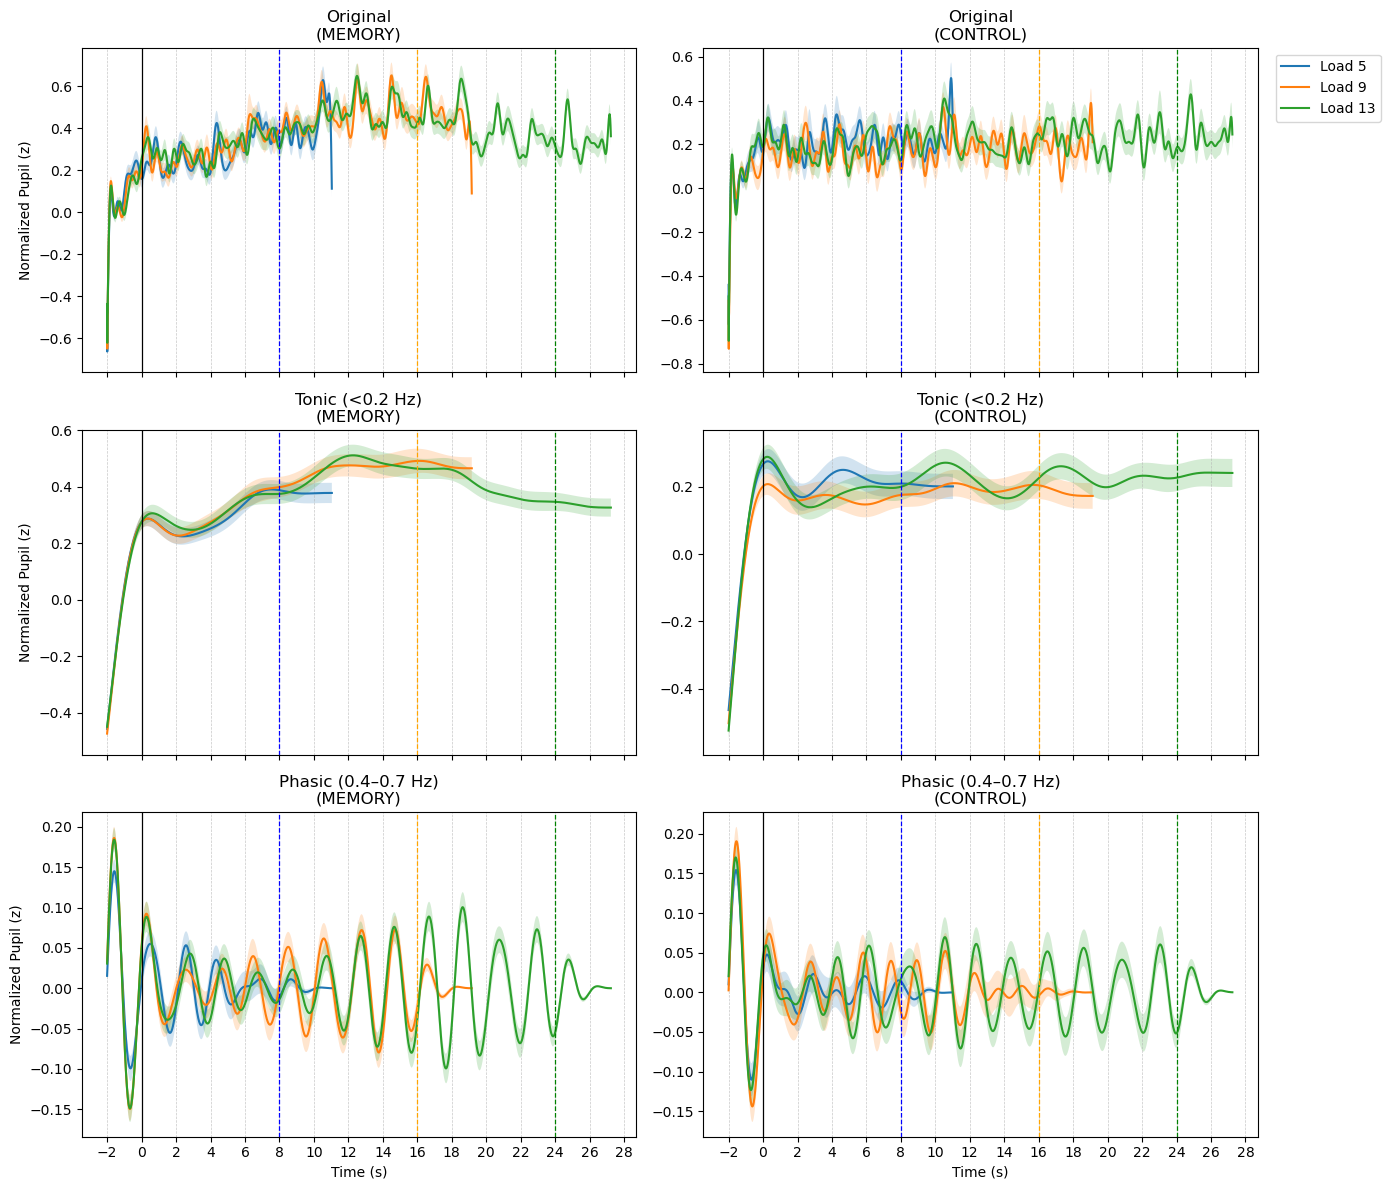

In [ ]:
EPOCHS_ROOT_EEG2 = pathlib.Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_hilbert")
all_epochs_eeg2 = load_epochs_eeg(EPOCHS_ROOT_EEG2, chan="F1")

# IMPORTANT: use the *components* function here
mem, ctrl = group_and_average_components(
    all_epochs_eeg2,
    low_fc=0.25,
    band=(0.4, 0.7), 
    x_plot="signal"
)
{'orig': [], 'tonic': [], 'phasic': []}
plot_components(mem, ctrl, savefig=pathlib.Path("fig_components.png"))

In [2]:
from __future__ import annotations
import pathlib
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from typing import List, Tuple

# -------- CONFIG --------
EEG_IN_ROOT  = pathlib.Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2")
EEG_OUT_SLOW = EEG_IN_ROOT.parent / "eeg_slow"
EEG_OUT_FAST = EEG_IN_ROOT.parent / "eeg_fast"

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']
# tonic (slow) cutoff — pick to match pupil or tighter for EEG
TONIC_LP= 0.2

# Choose phasic band:
#   "match_pupil"  -> (0.4, 0.7) Hz
#   "eeg_slowerp"  -> (0.2, 1.0) Hz (recommended for EEG from your PSD)
FAST_BAND_MODE = "match_pupil"  # "match_pupil" or "eeg_slowerp"

BANDS = {
    "match_pupil": (0.4, 0.7),
    "eeg_slowerp": (0.2, 1.0),
}
FAST_BP = BANDS[FAST_BAND_MODE]

# -------- FILTER HELPERS --------
def _fs_from_time(t: np.ndarray) -> float:
    dt = np.diff(t)
    return 1.0 / np.median(dt)

def _butter(btype: str, fs: float, fc, order=4):
    ny = fs/2
    if btype == "low":
        wn = float(fc)/ny
        b,a = butter(order, wn, btype="low")
    elif btype == "band":
        lo,hi = fc
        b,a = butter(order, [lo/ny, hi/ny], btype="band")
    else:
        raise ValueError("btype must be 'low' or 'band'")
    return b,a

def _filtfilt_safe(x: np.ndarray, b, a) -> np.ndarray:
    # works for 1D or 2D (samples x channels)
    x = np.asarray(x)
    padlen = max(1, min(3*max(len(a), len(b)), x.shape[0]-1))
    if x.ndim == 1:
        return filtfilt(b, a, x, padlen=padlen)
    out = np.empty_like(x, dtype=float)
    for i in range(x.shape[1]):
        out[:, i] = filtfilt(b, a, x[:, i], padlen=padlen)
    return out


def _available_channels(df: pd.DataFrame, wanted: List[str]) -> List[str]:
    return [ch for ch in wanted if ch in df.columns and pd.api.types.is_numeric_dtype(df[ch])]

def process_one_trial(csv_path: pathlib.Path, chans: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = pd.read_csv(csv_path)
    tcol = "time"
    use_ch = _available_channels(df, chans)
    if not use_ch:
        raise ValueError(f"No requested channels found in {csv_path.name}")

    t = df[tcol].to_numpy(float)
    X = df[use_ch].to_numpy(float)
    fs = _fs_from_time(t)

    # tonic (low pass)
    b_lp, a_lp = _butter("low", fs, TONIC_LP, order=4)
    X_slow = _filtfilt_safe(X, b_lp, a_lp)

    # phasic (band pass)
    b_bp, a_bp = _butter("band", fs, FAST_BP, order=4)
    X_fast = _filtfilt_safe(X, b_bp, a_bp)

    slow_df = pd.DataFrame(X_slow, columns=use_ch)
    fast_df = pd.DataFrame(X_fast, columns=use_ch)
    slow_df.insert(0, "time", t)
    fast_df.insert(0, "time", t)
    return slow_df, fast_df

def write_trial(out_root: pathlib.Path, in_root: pathlib.Path, trial_csv: pathlib.Path, out_df: pd.DataFrame):
    rel = trial_csv.relative_to(in_root)
    out_path = out_root / rel
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_df.to_csv(out_path, index=False)

def process_tree(in_root: pathlib.Path, chans: List[str]):
    n = 0
    for trial_csv in in_root.glob("sub-*/*/*/trial_*.csv"):
        try:
            slow_df, fast_df = process_one_trial(trial_csv, chans)
        except Exception as e:
            print(f"[EEG] skip {trial_csv}: {e}")
            continue
        write_trial(EEG_OUT_SLOW, in_root, trial_csv, slow_df)
        write_trial(EEG_OUT_FAST, in_root, trial_csv, fast_df)
        n += 1
    print(f"[EEG] Wrote {n} filtered trials to:\n  slow={EEG_OUT_SLOW}\n  fast={EEG_OUT_FAST}")

if __name__ == "__main__":
    EEG_OUT_SLOW.mkdir(parents=True, exist_ok=True)
    EEG_OUT_FAST.mkdir(parents=True, exist_ok=True)
    process_tree(EEG_IN_ROOT, FRONTAL_MIDLINE)


[EEG] Wrote 10047 filtered trials to:
  slow=C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow
  fast=C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_fast


In [ ]:
# ---- INPUT ROOTS (edit if different) ----
PUPIL_IN_ROOT = pathlib.Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_processed_clara")

# ---- OUTPUT ROOTS (created if missing) ----
PUP_OUT_SLOW  = PUPIL_IN_ROOT.parent / "pupil_slow"
PUP_OUT_FAST  = PUPIL_IN_ROOT.parent / "pupil_fast"

# ---- Filter bands (Hz) ----
PUPIL_SLOW_LP = 0.25
PUPIL_FAST_BP = (0.4, 0.7)

# ====== UTILS ======
def _fs_from_time(t: np.ndarray) -> float:
    dt = np.diff(t)
    return float(1.0 / np.median(dt))

def th(btype: str, fs: float, fc, order=4):
    ny = fs/2
    if btype == "low":
        wn = float(fc)/ny
        b,a = butter(order, wn, btype="low")
    elif btype == "band":
        lo,hi = fc
        b,a = butter(order, [lo/ny, hi/ny], btype="band")
    else:
        raise ValueError("btype must be 'low' or 'band'")
    return b,a

def _filtfilt_safe(x: np.ndarray, b, a) -> np.ndarray:
    # works for 1D or 2D (samples x channels)
    x = np.asarray(x)
    padlen = max(1, min(3*max(len(a), len(b)), x.shape[0]-1))
    if x.ndim == 1:
        return filtfilt(b, a, x, padlen=padlen)
    out = np.empty_like(x, dtype=float)
    for i in range(x.shape[1]):
        out[:, i] = filtfilt(b, a, x[:, i], padlen=padlen)
    return out


def _ensure_parent(path: pathlib.Path):
    path.parent.mkdir(parents=True, exist_ok=True)

def _write_series(path: pathlib.Path, time_s: np.ndarray, value: np.ndarray, colname: str):
    _ensure_parent(path)
    df = pd.DataFrame({"time": time_s, colname: value})
    df.to_csv(path, index=False)

# ====== PUPIL PROCESSING ======
def process_one_pupil(csv_path: pathlib.Path) -> Tuple[np.ndarray,np.ndarray,np.ndarray]:
    ep = pd.read_csv(csv_path, comment="#", header=None, names=["time(s)","diameter"])
    t = ep["time(s)"].to_numpy(float)
    x = ep["diameter"].to_numpy(float)
    fs = _fs_from_time(t)

    # slow: <0.25 Hz
    b,a = _butter("low", fs, PUPIL_SLOW_LP, order=4)
    slow = _filtfilt_safe(x, b, a)

    # fast: 0.2–1.0 Hz band
    b,a = _butter("band", fs, PUPIL_FAST_BP, order=4)
    fast = _filtfilt_safe(x, b, a)

    return t, slow, fast

def process_pupil_tree(in_root: pathlib.Path, out_slow: pathlib.Path, out_fast: pathlib.Path) -> int:
    n = 0
    for trial_csv in in_root.glob("sub-*/*/*/trial_*.csv"):
        rel = trial_csv.relative_to(in_root)
        t, slow, fast = process_one_pupil(trial_csv)
        _write_series(out_slow / rel, t, slow, "diameter")
        _write_series(out_fast / rel, t, fast, "diameter")
        n += 1
    print(f"[PUPIL] Saved {n} trials to:\n  slow: {out_slow}\n  fast: {out_fast}")
    return n


# ====== MAIN ======
if __name__ == "__main__":
    PUP_OUT_SLOW.mkdir(parents=True, exist_ok=True)
    PUP_OUT_FAST.mkdir(parents=True, exist_ok=True)

    n_pupil = process_pupil_tree(PUPIL_IN_ROOT, PUP_OUT_SLOW, PUP_OUT_FAST)

    print("\nDone.",
          f"\nPupil trials processed: {n_pupil}")


[PUPIL] Saved 7122 trials to:
  slow: C:\Users\cdd\Documents\Uni\Special_course\pupil_slow
  fast: C:\Users\cdd\Documents\Uni\Special_course\pupil_fast

Done. 
Pupil trials processed: 7122


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- helper: trim two (mean,sem) series to a shared time index
def _align_mean_sem(mean_a: pd.Series, sem_a: pd.Series,
                    mean_b: pd.Series, sem_b: pd.Series):
    common = mean_a.index.intersection(mean_b.index)
    # if indexes are floats with tiny rounding diffs, round first:
    if len(common) == 0:
        ia = mean_a.copy(); ib = mean_b.copy()
        ia.index = ia.index.round(3); ib.index = ib.index.round(3)
        sa = sem_a.copy(); sb = sem_b.copy()
        sa.index = sa.index.round(3); sb.index = sb.index.round(3)
        common = ia.index.intersection(ib.index)
        mean_a, sem_a, mean_b, sem_b = ia.loc[common], sa.loc[common], ib.loc[common], sb.loc[common]
    else:
        mean_a, sem_a, mean_b, sem_b = mean_a.loc[common], sem_a.loc[common], mean_b.loc[common], sem_b.loc[common]
    return common, mean_a, sem_a, mean_b, sem_b

def plot_memory_pupil_eeg(mem_pupil: dict,
                          mem_eeg: dict,
                          pupil_comp: str = "orig",
                          eeg_comp: str = "orig",
                          loads=(5, 9, 13),
                          pupil_label="Pupil (z)",
                          eeg_label="EEG θ (Fz, %)",
                          colors=("tab:blue","tab:orange")):
    """
    mem_pupil / mem_eeg: like the 'mem' dict returned by group_and_average_components()
        keys: 'orig'|'tonic'|'phasic' -> { load -> (mean_series, sem_series) }
    Creates 3 subplots (L05, L09, L13): pupil (left axis) overlaid with EEG (right axis).
    """
    fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=False, sharex=True)
    for k, load in enumerate(loads):
        ax = axs[k]
        # unpack
        mean_p, sem_p = mem_pupil[pupil_comp][load]
        mean_e, sem_e = mem_eeg[eeg_comp][load]

        # align time
        t, mean_p, sem_p, mean_e, sem_e = _align_mean_sem(mean_p, sem_p, mean_e, sem_e)

        # pupil (left axis)
        ax.plot(t, mean_p.values, color=colors[0], label="Pupil")
        ax.fill_between(t, (mean_p - sem_p).values, (mean_p + sem_p).values, alpha=0.2, color=colors[0])
        ax.set_title(f"Memory · Load {load:02d}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(pupil_label, color=colors[0])
        ax.tick_params(axis='y', labelcolor=colors[0])

        # EEG (right axis)
        ax2 = ax.twinx()
        ax2.plot(t, mean_e.values, color=colors[1], label="EEG")
        ax2.fill_between(t, (mean_e - sem_e).values, (mean_e + sem_e).values, alpha=0.2, color=colors[1])
        ax2.set_ylabel(eeg_label, color=colors[1])
        ax2.tick_params(axis='y', labelcolor=colors[1])

        # markers for timing (0, 8, 16, 24 s like your other fig)
        for x, c, ls in [(0, "k", "-"), (8, "b", "--"), (16, "orange", "--"), (24, "g", "--")]:
            ax.axvline(x, color=c, linestyle=ls, linewidth=0.8)
        ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
        ax.set_xticks(np.arange(-2, 29, 2))

    # a tiny joint legend
    lines = [plt.Line2D([0],[0],color=colors[0]), plt.Line2D([0],[0],color=colors[1])]
    axs[1].legend(lines, ["Pupil", "EEG"], loc="upper center")
    plt.tight_layout()
    plt.show()

# ---------------- EXAMPLE USAGE ----------------
# Build memory summaries for each modality (pupil & EEG).
# For pupil: x_plot="diameter" (or set pupil_comp="phasic" if you want the band-passed trace).
# For EEG:   pass x_plot="Fz" (theta power time series at Fz), and use eeg_comp="orig".
#
# all_epochs_pupil = load_epochs(PUPIL_EPOCHS_ROOT)  # your existing loader
# all_epochs_eeg   = load_epochs(EEG_EPOCHS_ROOT)
#
# mem_pupil, _ = group_and_average_components(all_epochs_pupil, low_fc=0.25, band=(0.4,0.7), x_plot="diameter")
# mem_eeg,   _ = group_and_average_components(all_epochs_eeg,   low_fc=0.25, band=(0.4,0.7), x_plot="Fz")  # filters are ignored if you use comp='orig'
#
# plot_memory_pupil_eeg(mem_pupil, mem_eeg,
#                       pupil_comp="orig",   # or "phasic"
#                       eeg_comp="orig",     # keep "orig" for EEG
#                       loads=(5,9,13),
#                       pupil_label="Pupil (z)",
#                       eeg_label="EEG θ (Fz, %)")


In [4]:
all_epochs_pupil = load_epochs_pupil(EPOCHS_ROOT_PUPIL)  # your existing loader
all_epochs_eeg   = load_epochs_eeg(EPOCHS_ROOT_EEG)

Loading sub-032…
Loading sub-033…
Loading sub-034…
Loading sub-035…
Loading sub-036…
Loading sub-038…
Loading sub-039…
Loading sub-040…
Loading sub-041…
Loading sub-042…
Loading sub-043…
Loading sub-044…
Loading sub-045…
Loading sub-046…
Loading sub-047…
Loading sub-048…
Loading sub-049…
Loading sub-050…
Loading sub-051…
Loading sub-052…
Loading sub-053…
Loading sub-054…
Loading sub-055…
Loading sub-056…
Loading sub-057…
Loading sub-058…
Loading sub-059…
Loading sub-060…
Loading sub-061…
Loading sub-062…
Loading sub-063…
Loading sub-064…
Loading sub-065…
Loading sub-067…
Loading sub-068…
Loading sub-069…
Loading sub-070…
Loading sub-071…
Loading sub-072…
Loading sub-073…
Loading sub-074…
Loading sub-075…
Loading sub-076…
Loading sub-077…
Loading sub-079…
Loading sub-080…
Loading sub-081…
Loading sub-082…
Loading sub-083…
Loading sub-085…
Loading sub-086…
Loading sub-087…
Loading sub-088…
Loading sub-089…
Loading sub-091…
Loading sub-092…
Loading sub-093…
Loading sub-095…
Loading sub-09

In [5]:
mem_pupil, _ = group_and_average_components(all_epochs_pupil, low_fc=0.25, band=(0.4,0.7), x_plot="diameter")
mem_eeg,   _ = group_and_average_components(all_epochs_eeg,   low_fc=0.2, band=(0.4,0.7), x_plot="signal")  # filters are ignored if you use comp='orig'

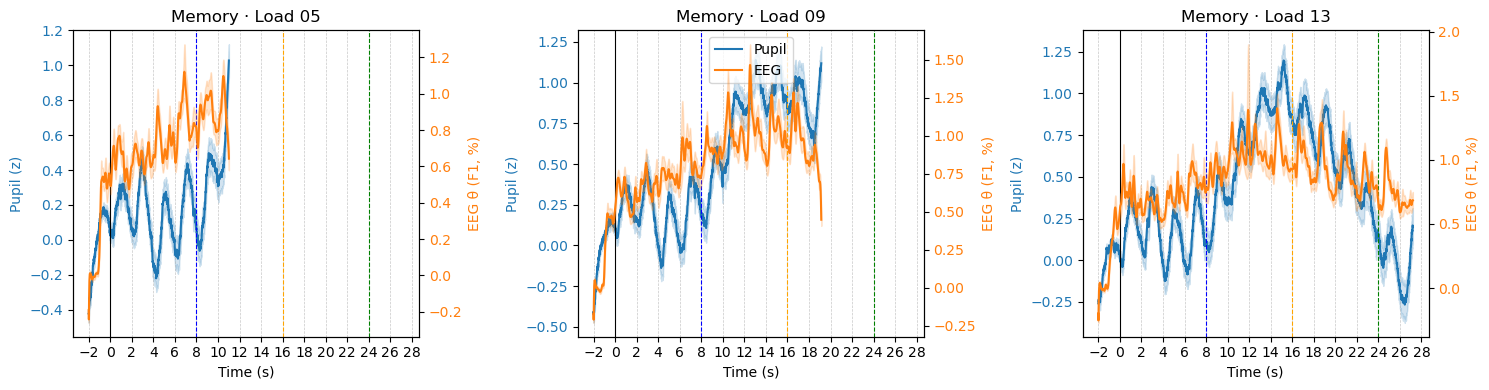

In [ ]:
plot_memory_pupil_eeg(mem_pupil, mem_eeg,
                      pupil_comp="orig",  
                      eeg_comp="orig",    
                      loads=(5,9,13),
                      pupil_label="Pupil (z)",
                      eeg_label="EEG θ (F1, %)")

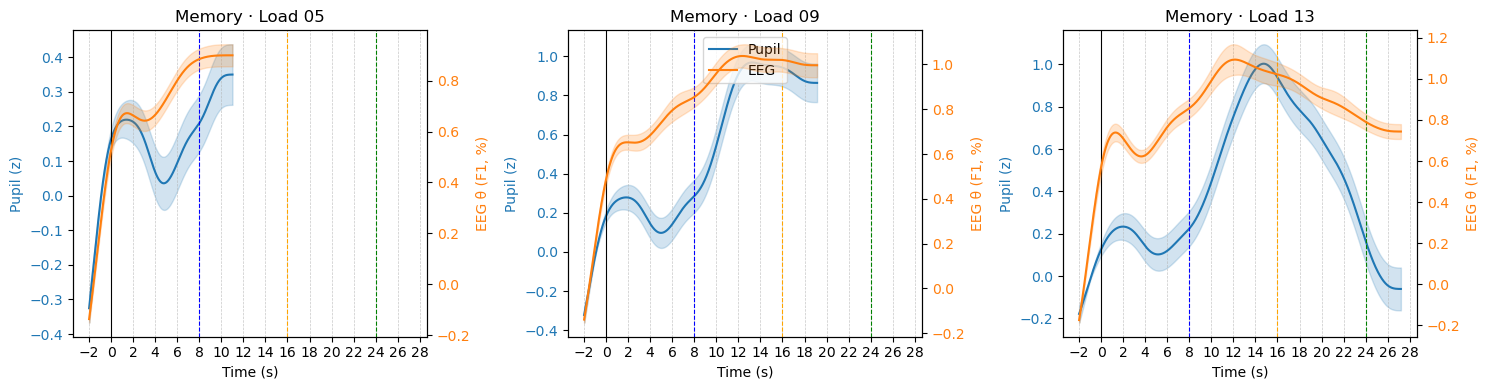

In [8]:
plot_memory_pupil_eeg(mem_pupil, mem_eeg,
                      pupil_comp="tonic",  
                      eeg_comp="tonic",    
                      loads=(5,9,13),
                      pupil_label="Pupil (z)",
                      eeg_label="EEG θ (F1, %)")

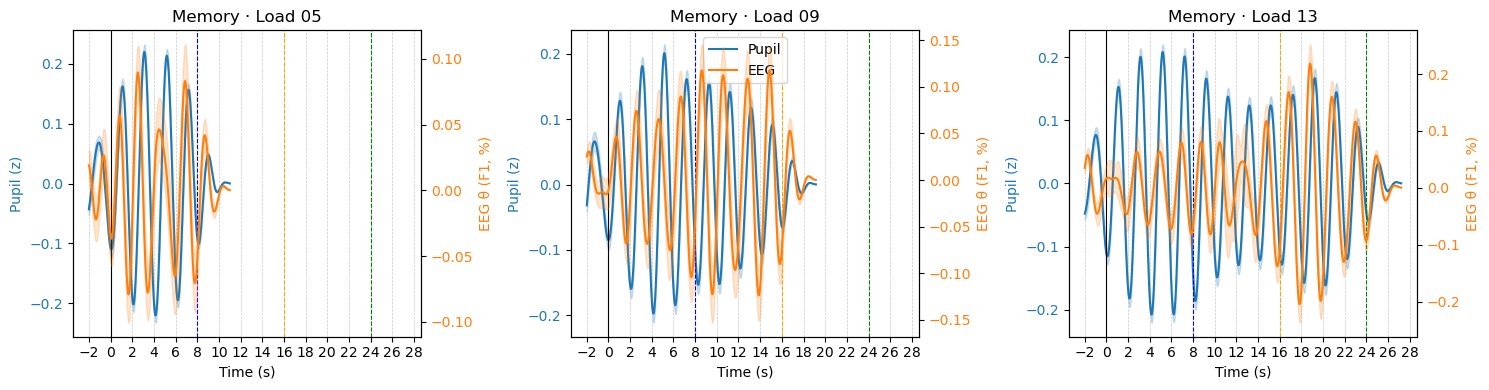

In [9]:
plot_memory_pupil_eeg(mem_pupil, mem_eeg,
                      pupil_comp="phasic",  
                      eeg_comp="phasic",    
                      loads=(5,9,13),
                      pupil_label="Pupil (z)",
                      eeg_label="EEG θ (F1, %)")